# 📉 Previsão de Churn de Clientes — Telecom

### Prevendo quais clientes têm mais chance de cancelar o serviço

**Contexto do problema:** uma empresa de telecomunicações está perdendo clientes (churn) e quer
antecipar quais assinantes têm maior probabilidade de cancelar o serviço, para que a área de
retenção possa agir **antes** que isso aconteça.

**Objetivo:** construir um modelo de classificação binária (`Churn = Yes/No`) usando os dados
cadastrais, contratuais e de consumo de cada cliente.

**Base de dados:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7.043 clientes, 21 colunas.

Este notebook segue o método **CRISP-DM** (Cross Industry Standard Process for Data Mining), dividido em:

1. **Data Understanding** — entender os dados (EDA)
2. **Data Preparation** — limpar e preparar os dados para modelagem
3. **Modelagem** — Regressão Logística
4. **Modelagem** — Random Forest
5. **Tuning** — otimização de hiperparâmetros (GridSearchCV)
6. **Avaliação final** — comparação entre modelos


## ⚙️ Setup do ambiente

Importamos as bibliotecas usadas em todas as etapas do projeto.


In [2]:
# Análise de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Divisão da base de dados
from sklearn.model_selection import train_test_split, GridSearchCV

# Tratamento dos dados categóricos e numéricos
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Modelos de classificação
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score,
                              precision_score, recall_score, f1_score, classification_report)

pd.set_option('display.max_columns', None)

---
# Etapa 01) Análise Exploratória dos Dados (Data Understanding)

Antes de qualquer modelagem, precisamos entender a estrutura, qualidade e os padrões da base de dados.

### Importar a base de dados

In [3]:
df = pd.read_csv('../data/Telecom_Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Estrutura geral

Verificamos o tamanho da base, os tipos de cada coluna e a existência de valores nulos.


In [4]:
print('Formato do dataset (linhas, colunas):', df.shape)
df.info()

Formato do dataset (linhas, colunas): (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object

> **Observação importante:** a coluna `TotalCharges` aparece como tipo `object` (texto), quando
> deveria ser numérica. Isso costuma acontecer quando existem valores em branco escondidos como
> strings (`' '`). Vamos confirmar isso e tratar na etapa de preparação dos dados.


In [5]:
# Verificando a quantidade de nulos "óbvios"
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Estatísticas descritivas das colunas numéricas
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Balanceamento da variável alvo (Churn)

Verificamos quantos clientes cancelaram (`Yes`) e quantos permaneceram (`No`).

In [7]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df['Churn'].value_counts(normalize=True).round(4) * 100

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

> **Insight:** a base é **desbalanceada** — cerca de **73,5%** dos clientes não cancelaram e
> **26,5%** cancelaram. Isso é relevante para a modelagem: a acurácia simples pode enganar (um
> modelo que sempre prevê "não cancela" já acertaria ~73% das vezes). Por isso vamos acompanhar
> também métricas como *balanced accuracy*, *precision*, *recall* e *f1-score*.


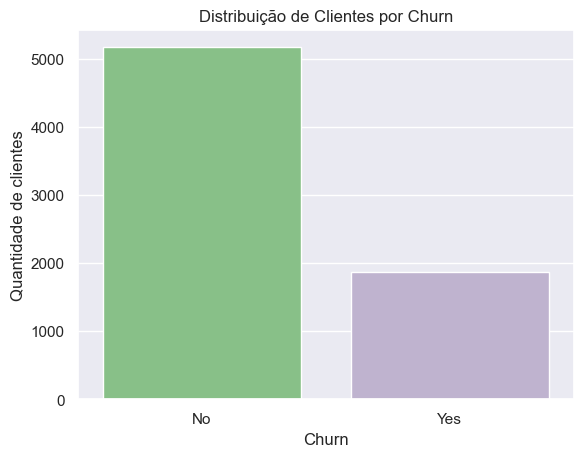

In [9]:
sns.set_palette("Accent")
sns.set_style("darkgrid")

churn_counts = df.groupby("Churn")['customerID'].count().reset_index()
ax = sns.barplot(data=churn_counts, x="Churn", y="customerID")
ax.set_title("Distribuição de Clientes por Churn")
ax.set_ylabel("Quantidade de clientes")
plt.show()

### Visão geral das variáveis categóricas

In [10]:
for column in df.select_dtypes(include='object').columns:
    print(f"--- {column} ---")
    print(df[column].value_counts())
    print()

--- customerID ---
customerID
7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

--- OnlineBackup --

### Churn por tipo de contrato

Contratos `Month-to-month` (mensal, sem fidelidade) tendem a ter muito mais cancelamento do que
contratos anuais/bianuais, pois o cliente não tem barreira de saída.

In [12]:
churn_contract = df.query("Churn == 'Yes'").groupby("Contract")['customerID'].count().reset_index()
churn_contract

,Contract,customerID
0,Month-to-month,1655
1,One year,166
2,Two year,48


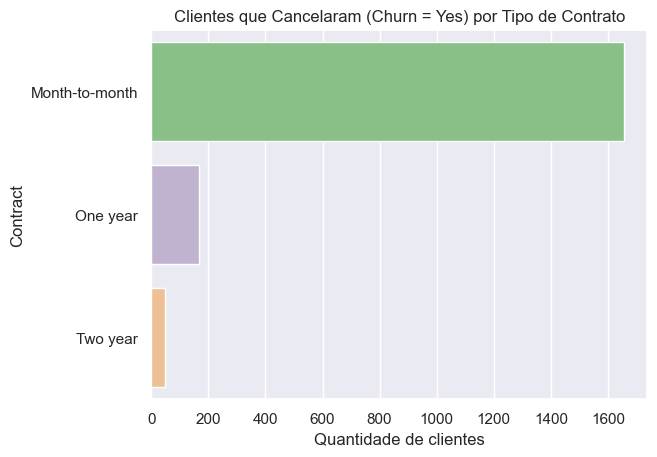

In [13]:
ax = sns.barplot(data=churn_contract, x="customerID", y="Contract")
ax.set_title("Clientes que Cancelaram (Churn = Yes) por Tipo de Contrato")
ax.set_xlabel("Quantidade de clientes")
plt.show()

> **Insight:** dos 1.869 clientes que cancelaram, **1.655 (~88,6%)** estavam em contratos
> `Month-to-month`. Esse é um dos sinais mais fortes de churn na base — sugere que incentivar
> migração para planos anuais pode ser uma ação de retenção eficaz.


### Churn por gênero

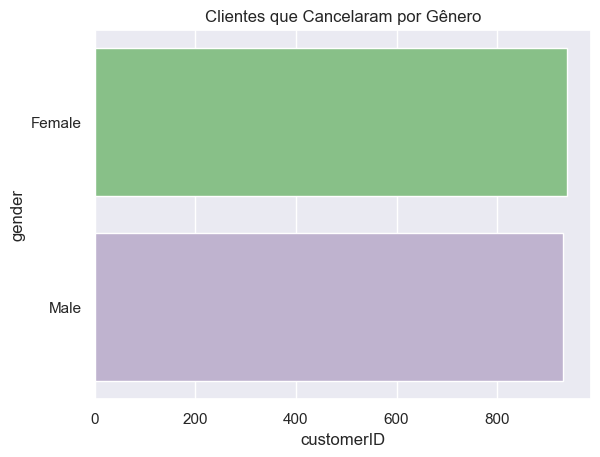

In [14]:
churn_gender = df.query("Churn == 'Yes'").groupby("gender")['customerID'].count().reset_index()
ax = sns.barplot(data=churn_gender, x="customerID", y="gender")
ax.set_title("Clientes que Cancelaram por Gênero")
plt.show()


> **Insight:** o churn é praticamente **igual entre gêneros** (939 mulheres vs. 930 homens) —
> gênero não parece ser uma variável relevante para prever cancelamento.

### Churn por tipo de internet

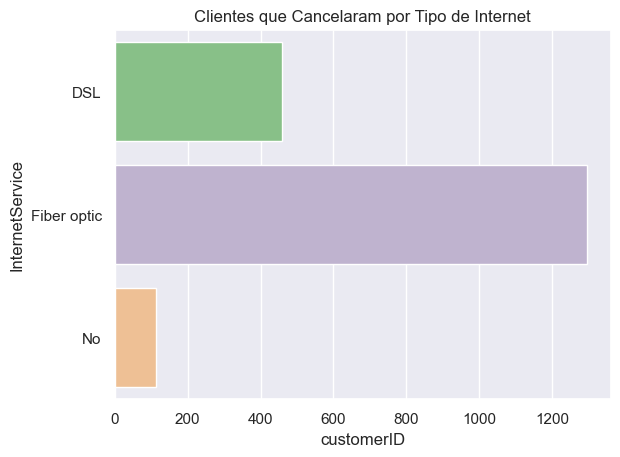

In [15]:
churn_internet = df.query("Churn == 'Yes'").groupby("InternetService")['customerID'].count().reset_index()
ax = sns.barplot(data=churn_internet, x="customerID", y="InternetService")
ax.set_title("Clientes que Cancelaram por Tipo de Internet")
plt.show()

> **Insight:** clientes com internet **Fibra Óptica** cancelam muito mais (1.297 de 1.869, ~69%)
> do que clientes com DSL ou sem internet. Pode indicar problemas de qualidade/preço no serviço de
> fibra, ou um perfil de cliente mais exigente/sensível a preço.



### Churn por uso de Streaming TV

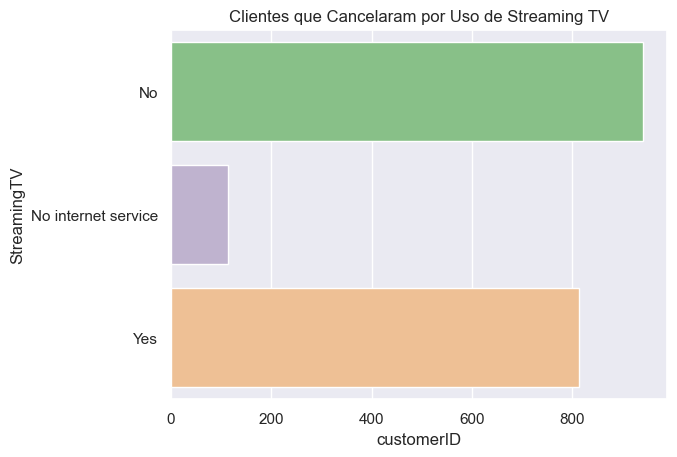

In [16]:
churn_streaming = df.query("Churn == 'Yes'").groupby("StreamingTV")['customerID'].count().reset_index()
ax = sns.barplot(data=churn_streaming, x="customerID", y="StreamingTV")
ax.set_title("Clientes que Cancelaram por Uso de Streaming TV")
plt.show()

### Relação entre variáveis numéricas

Usamos um `pairplot` para visualizar a relação entre `tenure` (tempo de contrato),
`MonthlyCharges` (mensalidade) e `TotalCharges` (total pago), segmentado por Churn.

c:\Users\vivid\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


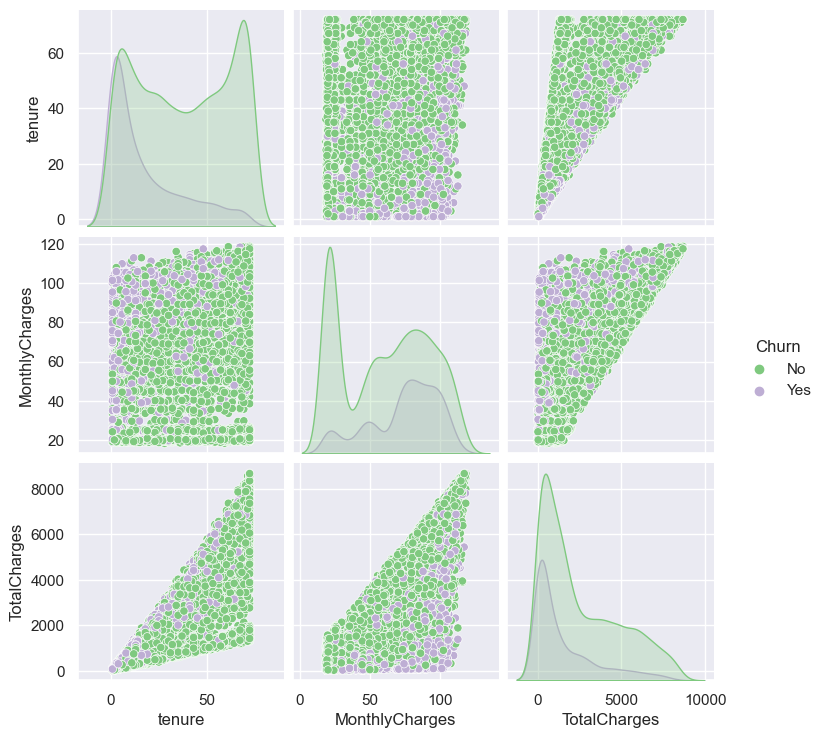

In [17]:
df_num = df.copy()
df_num['TotalCharges'] = pd.to_numeric(df_num['TotalCharges'], errors='coerce')

sns.pairplot(df_num[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].dropna(), hue='Churn')
plt.show()

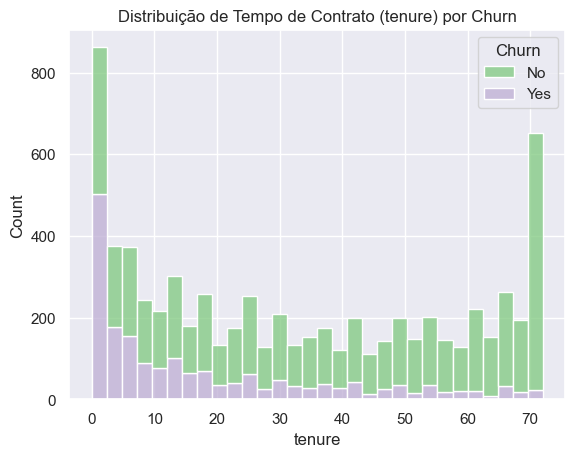

In [18]:
ax = sns.histplot(data=df_num, x='tenure', hue='Churn', multiple='stack', bins=30)
ax.set_title("Distribuição de Tempo de Contrato (tenure) por Churn")
plt.show()

> **Insight:** clientes com **tenure baixo** (poucos meses de casa) concentram a maior parte do
> churn. Isso é coerente com o insight de contratos mensais: clientes recém-chegados, sem
> fidelidade, cancelam mais cedo. Já clientes com mensalidade alta também parecem ter mais churn,
> o que sugere sensibilidade a preço.
